## Phase 4: Aesthetic RGB Image Creation
This notebook aligns, neutralizes, and stretches flux-calibrated FITS files  to create a scientifically accurate and aesthetically pleasing color image.

In [2]:
# CELL 1: Imports and Setup
import numpy as np
from astropy.io import fits
import astroalign as aa
from astropy.visualization import make_lupton_rgb
import matplotlib.pyplot as plt
import os

# Set plot parameters for large, high-res inline images
plt.rcParams['figure.figsize'] = (12, 12)
plt.rcParams['image.origin'] = 'lower' # Astronomical standard (0,0 at bottom left)

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [3]:
# CELL 2: Define File Paths
# Replace these with the actual paths to your Phase 3 flux-calibrated FITS files.
# We map R -> Red, V -> Green, and B -> Blue.

base_dir = "/media/plato/imtiaz/image_processing/NGC7331_thairobotic/Flux_calibrated"

r_file = os.path.join(base_dir, "Master_NGC7331_R_Photo_Andor_DU934P_BV_60s_5fr_fluxcal.fits")
g_file = os.path.join(base_dir, "Master_NGC7331_V_Photo_Andor_DU934P_BV_60s_4fr_fluxcal.fits")
b_file = os.path.join(base_dir, "Master_NGC7331_B_Photo_Andor_DU934P_BV_60s_5fr_fluxcal.fits")

print("File paths configured.")

File paths configured.


In [6]:
# CELL 3: Load the Linear Flux-Calibrated Data
print("Loading FITS data into memory...")

# NOTE: FITS files are natively "Big-Endian" byte order, but modern processors 
# and libraries like Astroalign expect "Little-Endian". 
# We use .astype(float) to force the conversion and prevent buffer errors.
r_data = fits.getdata(r_file).astype(float)
g_data = fits.getdata(g_file).astype(float)
b_data = fits.getdata(b_file).astype(float)

print(f"Red channel shape: {r_data.shape}")
print(f"Green channel shape: {g_data.shape}")
print(f"Blue channel shape: {b_data.shape}")

Loading FITS data into memory...
Red channel shape: (1024, 1024)
Green channel shape: (1024, 1024)
Blue channel shape: (1024, 1024)


In [7]:
# CELL 4: Image Alignment (Registration)
# We use the R-band as the immovable "Master Reference" because it usually has the 
# highest signal-to-noise ratio. We warp the V and B bands to match its stars perfectly.

print("Aligning Green (V) to Red (R)...")
try:
    g_aligned, _ = aa.register(g_data, r_data)
    print(" -> Green alignment successful.")
except Exception as e:
    print(f" -> [WARNING] Green alignment failed: {e}")
    g_aligned = g_data

print("Aligning Blue (B) to Red (R)...")
try:
    b_aligned, _ = aa.register(b_data, r_data)
    print(" -> Blue alignment successful.")
except Exception as e:
    print(f" -> [WARNING] Blue alignment failed: {e}")
    b_aligned = b_data

Aligning Green (V) to Red (R)...
 -> Green alignment successful.
Aligning Blue (B) to Red (R)...
 -> Blue alignment successful.


In [8]:
# CELL 5: Background Neutralization (Sky Subtraction)
# Even calibrated images have some background skyglow. We subtract the median 
# to force the "empty space" in all three channels to perfectly equal zero (black).

print("Neutralizing sky background...")

r_sub = r_data - np.median(r_data)
g_sub = g_aligned - np.median(g_aligned)
b_sub = b_aligned - np.median(b_aligned)

# Prevent negative pixel anomalies (black clipping)
r_sub = np.clip(r_sub, 0, None)
g_sub = np.clip(g_sub, 0, None)
b_sub = np.clip(b_sub, 0, None)

print("Background neutralized.")

Neutralizing sky background...
Background neutralized.


In [11]:
# CELL 6: Non-Linear Stretching and Saturation
# This is the most crucial step. We use the Lupton Asinh stretch to map the linear 
# physical Janskys into a logarithmic scale that matches human vision.

# Janskys are tiny physical numbers (often 0.001 or smaller)! 
# Let's dynamically calculate a good baseline stretch based on your specific image's actual brightness:
p99 = np.percentile(r_sub, 99.5)
print(f"99.5th Percentile Brightness: {p99:.6f} Jy")

# --- TWEAK THESE PARAMETERS ---
stretch_q = 8.0               # Softens the bright cores (Higher = softer cores, less white clipping)
stretch_scale = p99 * 0.5     # Dynamic scaling! (Lower multiplier = brighter faint details)
saturation = 1.2              # Color punch multiplier (1.0 = normal, >1.0 = more vibrant)
# ------------------------------

print(f"Applying Lupton RGB Stretch (Q={stretch_q}, Scale={stretch_scale:.6f})...")

rgb_image = make_lupton_rgb(
    r_sub * saturation, 
    g_sub * saturation, 
    b_sub * saturation, 
    Q=stretch_q, 
    stretch=stretch_scale
)

print("RGB Array generated!")

99.5th Percentile Brightness: 0.000028 Jy
Applying Lupton RGB Stretch (Q=8.0, Scale=0.000014)...
RGB Array generated!


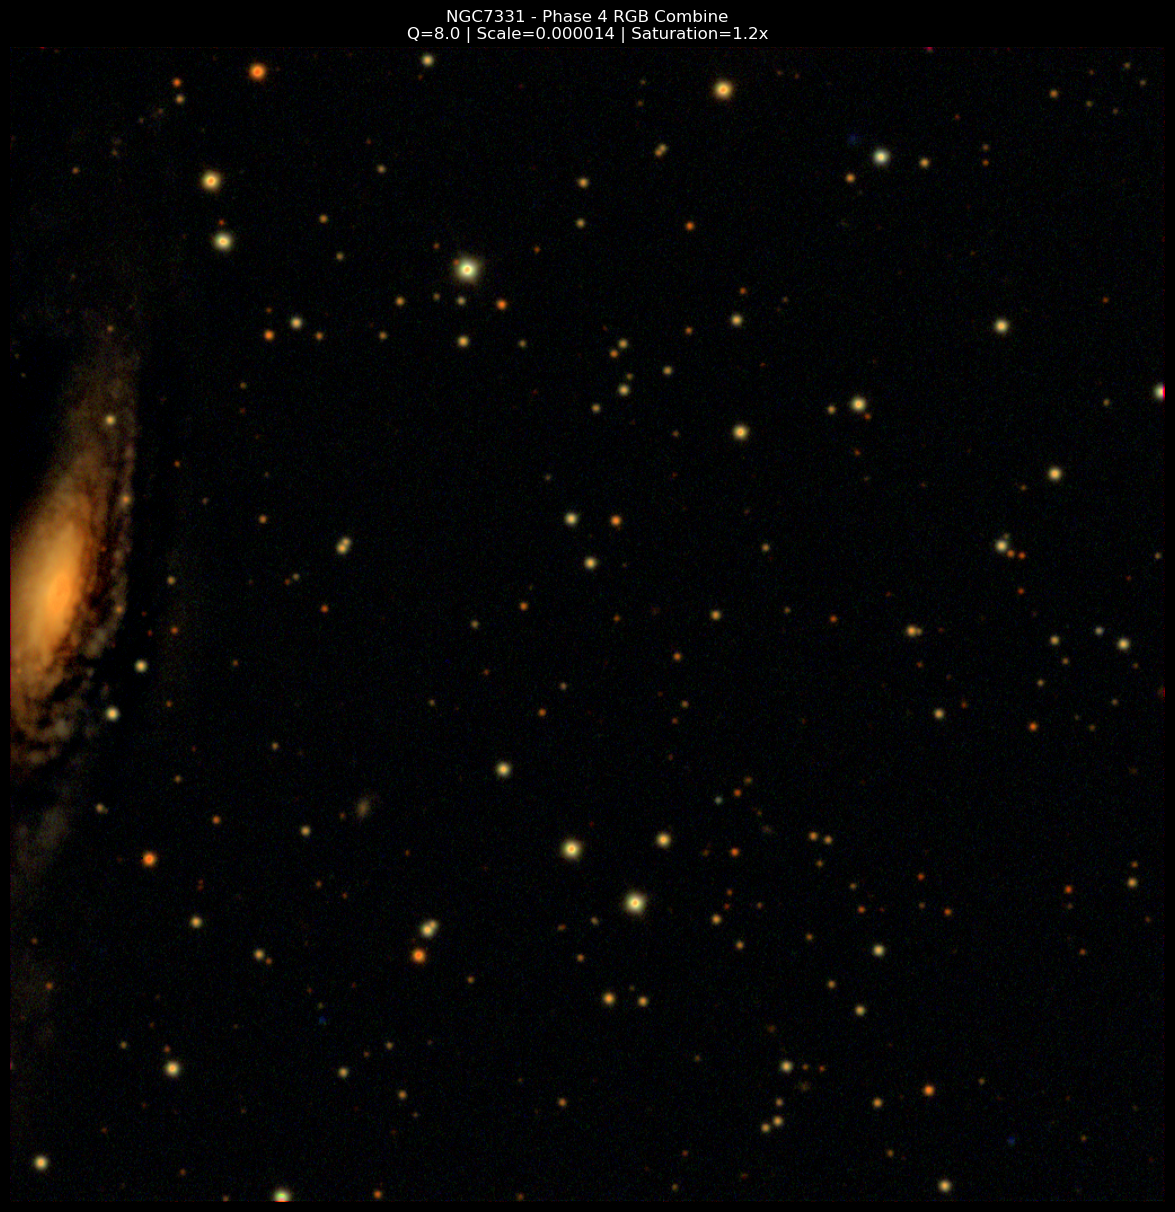

In [12]:
# CELL 7: Visualize the Result
# Plot the final image right here in the Jupyter Notebook

plt.figure(figsize=(15, 15))
plt.title(f"NGC7331 - Phase 4 RGB Combine\nQ={stretch_q} | Scale={stretch_scale:.6f} | Saturation={saturation}x", color='white')
plt.imshow(rgb_image)
plt.axis('off')

# Change notebook background to dark to better view the image
plt.gcf().set_facecolor('black')
plt.show()